In [1]:
import sys
sys.path.append('../..')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
from truncation_estimate import trunc_by_graph_estimate
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
import scipy as sp
from IPython.display import display, Math
from multiprocessing import Pool
import pandas as pd

#### Population transfer

In [2]:
drive_phi, drive_theta = False, True
# drive_phi, drive_theta = True, False
truc1 = 100

# folder = '../../data/3ncut_one_zeropi/'
folder = "/home/eweissler/src/zp_data/"
truncation=1000
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc={truncation}_3ncut.h5').energy_table
n_theta0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc={truncation}_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc={truncation}_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]
if drive_phi:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = n_phi0
if drive_theta:
    w_trans_1 = eval0[7] - eval0[0]
    w_trans_2 = eval0[7] - eval0[2]
    drive_term = n_theta0

In [3]:
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [39.991616, 0.105045, 0.028058, 0.002171, 0.003988] # theta
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [120.004766,0.209273,0.104767,0.341188,0.360503] # phi
H0 = qt.Qobj(np.diag(eval0))
hilbert_space = np.arange(truc1).tolist()
tlist = np.linspace(0, tg,  num=10* int(tg) )  # total time
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        }

H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]
states = [qt.basis(truc1, i) for i in range(truc1)]

result = {}
logi_state = [0, 2]
logi_index = [hilbert_space.index(i) for i in logi_state]
for jdx, state_j in enumerate(logi_index):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=qt.Options(store_states=True, nsteps=1e4)  )

In [4]:
if drive_theta:
    core_states = [0, 2, 7]
    d = "theta"
else:
    core_states = [0, 2, 9]
    d = "phi"
hspace_reduced = trunc_by_graph_estimate(1000, core_states, drive_term, eval0, [w_trans_1, w_trans_2], [drive_amp_A, drive_amp_B])

100%|██████████| 1000/1000 [01:56<00:00,  8.59it/s]


In [7]:
hspace_reduced.index(4)

41

In [28]:
pulse_args = {'drive_amp_A': drive_amp_A ,
            'drive_freq_A': w_trans_1 + 2*np.pi*detune_A,
            'drive_amp_B': drive_amp_B ,
            'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
            'gate_time': tg,
             'alpha_A': 0,
             'alpha_B': 0 }
# Save to npz for julia
np.savez(f"H_{d}.npz", H0=H0, drive=drive_term, w_trans_1=w_trans_1, w_trans_2=w_trans_2, hspace_reduced=hspace_reduced, hspace_full=np.arange(truncation), **pulse_args)


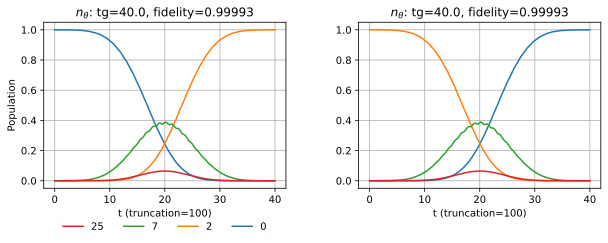

In [12]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_theta = [0, 2, 7, 25] # theta
state_interest = state_theta if drive_theta else state_phi
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        if state in state_interest:
            ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    # ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99993')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

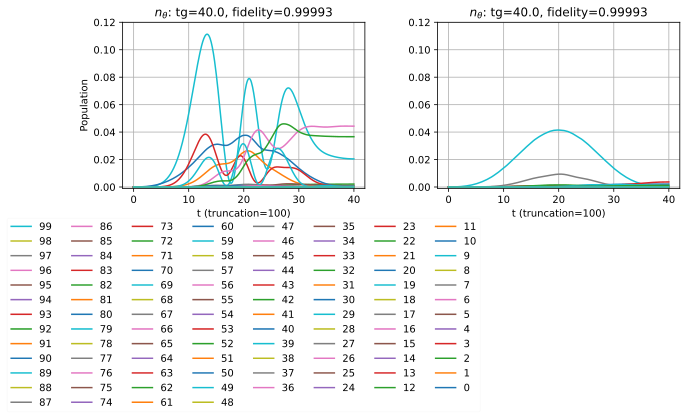

In [8]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in state_interest:
        ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99993')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)